# Keras 儲存與載入訓練好的模型或參數
### Iris,  sepal: 萼片,   petal: 花瓣

##### data from: https://www.kaggle.com/uciml/iris/data
##### code modified from: https://www.kaggle.com/pratik2901/sequential-ann-and-visualization
##### code modified from: https://morvanzhou.github.io/tutorials/machine-learning/keras/3-1-save/
##### Save & reload 保存提取, 作者: Alice 编辑: 莫烦 2016-10-30

# (1) Load and prepare the data

In [1]:
import warnings
warnings.simplefilter(action='ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf

In [2]:
tf.__version__

'2.13.0'

In [3]:
seed = 5
np.random.seed(seed)

In [4]:
iris = pd.read_csv("..\input\Iris.csv")

In [5]:
dataset = iris.values
X = dataset[:,1:5].astype(float)
#print(X[0:5,:])

In [6]:
# convert text into vectors
# method #2
Y = dataset[:,5]
encoder = LabelEncoder()
encoder.fit(Y)
encoded_Y = encoder.transform(Y)
# print(Y[0:5])
# print(encoded_Y)

In [7]:
answer_Y = tf.keras.utils.to_categorical(encoded_Y)
# print(answer_Y[0:5])

# (2)  Sequential Based ANN

In [8]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(8, input_dim=4, activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(3, activation=tf.nn.softmax))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 40        
                                                                 
 dense_1 (Dense)             (None, 3)                 27        
                                                                 
Total params: 67 (268.00 Byte)
Trainable params: 67 (268.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
history = model.fit(X,answer_Y,epochs=30,batch_size=5)

Epoch 1/30
30/30 [==============================] - 1s 1ms/step - loss: 1.3235 - accuracy: 0.0867 
Epoch 2/30
30/30 [==============================] - 0s 1ms/step - loss: 1.1686 - accuracy: 0.1067
Epoch 3/30
30/30 [==============================] - 0s 1ms/step - loss: 1.0411 - accuracy: 0.1000
Epoch 4/30
30/30 [==============================] - 0s 1ms/step - loss: 0.9198 - accuracy: 0.1200
Epoch 5/30
30/30 [==============================] - 0s 1ms/step - loss: 0.8230 - accuracy: 0.1933
Epoch 6/30
30/30 [==============================] - 0s 1ms/step - loss: 0.7463 - accuracy: 0.5333
Epoch 7/30
30/30 [==============================] - 0s 1ms/step - loss: 0.6884 - accuracy: 0.6133
Epoch 8/30
30/30 [==============================] - 0s 1ms/step - loss: 0.6451 - accuracy: 0.5267
Epoch 9/30
30/30 [==============================] - 0s 1ms/step - loss: 0.6124 - accuracy: 0.6400
Epoch 10/30
30/30 [==============================] - 0s 1ms/step - loss: 0.5802 - accuracy: 0.6667
Epoch 11/30
30/30 

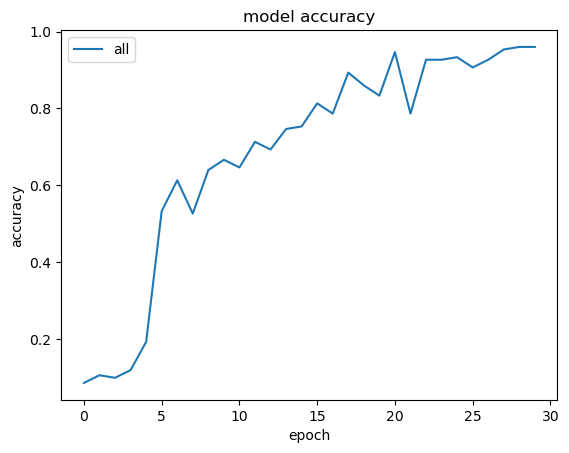

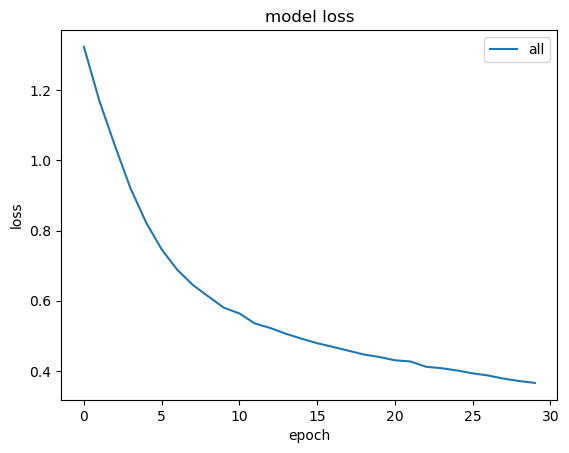

In [11]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['all'], loc='upper left')
plt.savefig('acc.png')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['all'], loc='upper right')
plt.savefig('loss.png')
plt.show()

# (3)   如何儲存神經網絡，以後想要用的時候，可以直接提取。

# 儲存模型

### 訓練完模型之後，可以列印預測的結果，然後再儲存模型。
### 儲存的時候只需要用 model.save，給它加一個名字，就可以用 keras 的格式保存起來。
### 儲存完模型之後，刪掉它，後面再驗證是否儲存成功。

In [12]:
# 將模型儲存至 HDF5 檔案中 
print('test before save: ', model.predict(X[0:2]))
model.save('my_model.keras')  

1/1 [==============================] - 0s 178ms/step
test before save:  [[0.9653086  0.02530422 0.00938719]
 [0.954162   0.03550552 0.01033243]]


In [13]:
del model  # deletes the existing model

# (4)  導入模型並應用

### 導入儲存好的模型，再執行一遍預測，與之前預測的結果比較，會發現結果是一樣的。

In [14]:
# load keras file
from keras.models import load_model

model = load_model('my_model.keras')
print('test after load: ', model.predict(X[0:2]))

1/1 [==============================] - 0s 149ms/step
test after load:  [[0.9653086  0.02530422 0.00938719]
 [0.954162   0.03550552 0.01033243]]


In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 40        
                                                                 
 dense_1 (Dense)             (None, 3)                 27        
                                                                 
Total params: 67 (268.00 Byte)
Trainable params: 67 (268.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
history = model.fit(X,answer_Y,epochs=30,batch_size=5)

Epoch 1/30
30/30 [==============================] - 1s 1ms/step - loss: 0.3588 - accuracy: 0.9600
Epoch 2/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3582 - accuracy: 0.9200
Epoch 3/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3541 - accuracy: 0.9333
Epoch 4/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3427 - accuracy: 0.9200
Epoch 5/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3346 - accuracy: 0.9600
Epoch 6/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3315 - accuracy: 0.9733
Epoch 7/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3273 - accuracy: 0.9667
Epoch 8/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3285 - accuracy: 0.9667
Epoch 9/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3162 - accuracy: 0.9600
Epoch 10/30
30/30 [==============================] - 0s 1ms/step - loss: 0.3106 - accuracy: 0.9600
Epoch 11/30
30/30 [

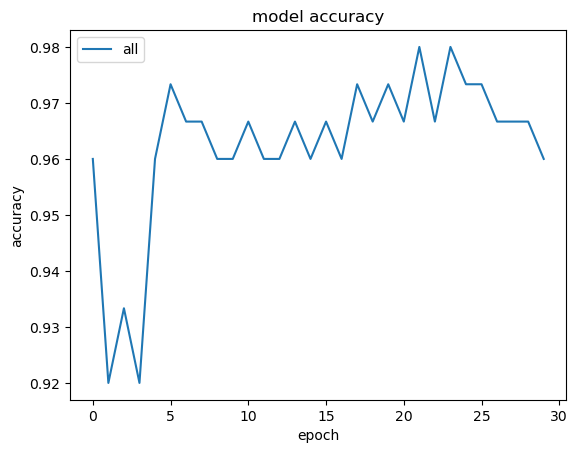

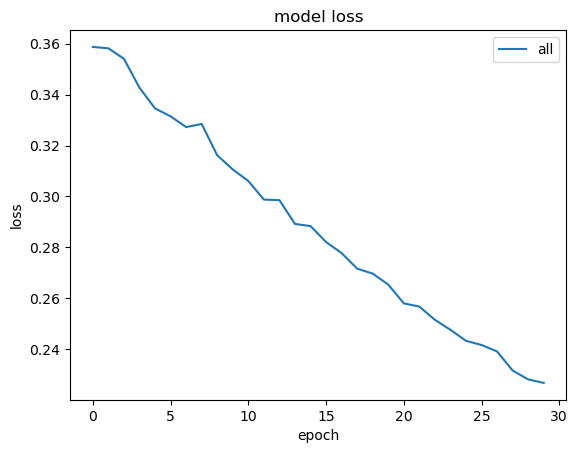

In [17]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['all'], loc='upper left')
plt.savefig('acc.png')
plt.show()

# summarize history for loss
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['all'], loc='upper right')
plt.savefig('loss.png')
plt.show()

In [18]:
scores = model.evaluate(X,answer_Y)

5/5 [==============================] - 0s 2ms/step - loss: 0.2219 - accuracy: 0.9667


In [19]:
print("Accuracy:%.2f%%"%(scores[1]*100))

Accuracy:96.67%


In [20]:
predict_probability = model.predict(X) 
prediction = np.argmax(predict_probability,axis=1)
print(prediction)

5/5 [==============================] - 0s 1ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 1
 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [21]:
print(encoded_Y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [22]:
pd.crosstab(encoded_Y,prediction,rownames=['label'],colnames=['predict'])

predict,0,1,2
label,,,
0,50,0,0
1,0,46,4
2,0,1,49
